# 들어가며

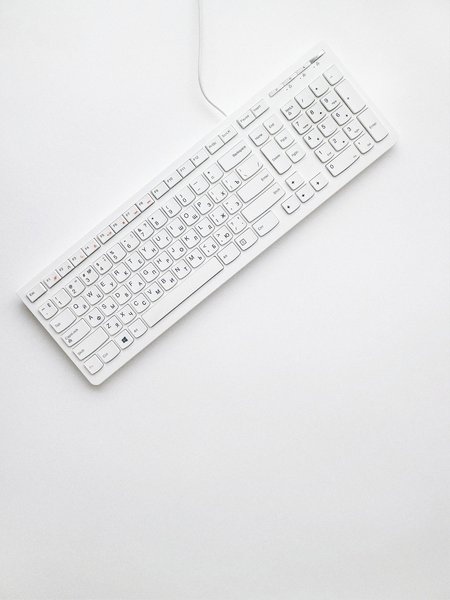

이전 시간에 멋진 **Sequence-to-Sequence** 구조를 배웠습니다. 두 개의 RNN 모듈을 Encoder-Decoder 구조로 결합하여 사용하는 Seq2seq은 그야말로 혁신이었습니다.

Seq2seq이 번역기에 최적화되어 있는 만큼, 이번 코스에선 **Seq2seq 기반 번역기를 직접 만들어보며** 그 구조를 이해해보도록 하겠습니다. 또한 Attention 기법을 추가하여 성능을 높여보기도 할 거고요!

실습에는 영어-스페인어 말뭉치를 사용하지만 직접 하실 프로젝트는 한국어-영어 말뭉치를 사용할 것입니다. 그럼 시작합시다!

**[아이스브레이킹] 지난 시간에 배운 Sequence-to-Sequence에 대해서 간단하게 생각해 볼까요?**

A. Sequence-to-Sequence 모델은 일련의 입력 시퀀스를 다른 일련의 출력 시퀀스로 변환하는 모델입니다.
이 모델은 대부분 자연어 처리에서 사용되며, 예를 들어 기계 번역, 챗봇, 요약, 질의응답 등의 작업에서 널리 사용됩니다.

## 학습 내용
---
2. 데이터 전처리

    필요한 데이터를 준비하고 전처리합니다.

3. 모델 설계

    Bahdanau Attention을 사용해서 코드 실습을 합니다.

4. 훈련하기 (1) Optimizer & Loss

    Encoder-Decoder 구조를 정의합니다.

5. 훈련하기 (2) train_step 구현하기

    Loss를 계산한 후 반환하는 함수를 학습합니다.

6. 훈련하기 (3) 훈련 시작하기

    학습을 진행하고 시각화합니다.

## 학습 목표
---
- 데이터를 필요에 맞게 전처리할 수 있다.
- Encoder-Decoder 구조를 이해할 수 있다.
- Encoder-Decoder 구조를 다른 사람에게 설명할 수 있다.

## 준비물
---
터미널을 열고 프로젝트를 위한 디렉토리를 생성해 주세요.

```
$ mkdir -p ~/aiffel/s2s_translation
```

실습에서는 한국어가 포함된 말뭉치를 사용하므로, 한국어를 잘 시각화하기 위한 준비가 필요합니다. 다만 *`matplotlib` 라이브러리의 기본 폰트는 한국어를 지원하지 않아요!* 올바른 Attention Map을 확인하기 위해 한국어를 지원하는 폰트로 변경해 주도록 합시다.

In [ ]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,032 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 124947 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/나눔 글꼴/나눔고딕/NanumFontSetup_TTF_GOTHIC/NanumGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumGothic


# 데이터 전처리

## 데이터 준비하기
---
먼저 프로젝트에 사용될 라이브러리를 `import` 하도록 합시다.

In [2]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else ('mps' if torch.mps.is_available() else 'cpu'))
print(torch.__version__)

2.10.0


데이터를 다운로드하는 데에는 `urllib.request.urlretrieve()` 함수를 사용할 겁니다. `urllib.request.urlretrieve()`함수는 URL로부터 데이터를 다운받고, `zip_ref.extractall()` 함수는 폴더 내 압축된 파일들을 찾아 해제까지 알아서 할 수 있는 똑똑한 함수랍니다! 아래 소스를 실행해 데이터를 다운로드받아주세요.

In [45]:
trans_lang= ['eng','spa','kor']

src_trans_lang='eng'
print(trans_lang)
trg_trans_lang=input('eng-> 무슨언어로번역하고 싶으신가요? (등록되지 않은 언어로 선택하면eng로 선택됩니다)')
trg_trans_lang=trg_trans_lang if trans_lang.count(src_trans_lang) else 'eng'

zip_code="{}-{}".format(trg_trans_lang,src_trans_lang)
dataset_dir = os.path.join(os.path.expanduser("/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/datasets"),zip_code)
os.makedirs(dataset_dir, exist_ok=True)
zip_path = os.path.join(dataset_dir,zip_code+'.zip')

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    link = "http://storage.googleapis.com/download.tensorflow.org/data/{}.zip".format(zip_code)
    print(link)
    urllib.request.urlretrieve(link, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir,zip_code)
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "{}.txt".format(trg_trans_lang))

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

['eng', 'spa', 'kor']


eng-> 무슨언어로번역하고 싶으신가요? (등록되지 않은 언어로 선택하면eng로 선택됩니다) kor


데이터셋 디렉토리: ['.DS_Store', 'kor-eng', 'kor-eng.zip']


다운로드받은 데이터를 읽어온 후, 형태를 확인해보도록 하죠!

## 데이터 전처리: 정제하기
---
데이터는 `\t` 기호를 기준으로 영어와 스페인어가 병렬 쌍을 이루고 있습니다. 고로 `\t` **기호를 매개변수로** `split()` **함수를 호출**하면 손쉽게 소스 문장과 타겟 문장을 분리할 수 있겠죠! 추가로 위 예시의 네 번째 문장을 보면 `¡` 같은 요상한 기호가 포함되어 있곤 합니다. 이 같은 특수문자는 **불필요한 노이즈로 작용**할 수 있기 때문에 정**제 과정에서 삭제**하도록 하겠습니다.

> 사실 스페인에서는 역 물음표(¿)와 역 느낌표(¡)를 일반적으로 사용합니다. 문장이 물음표나 느낌표로 끝난다면 해당 문장 맨 앞에 역으로 된 기호를 붙여준다고 해요. 이해를 돕기 위해 이상한 기호 취급을 하였으니 양해를 바랍니다!

정제는 아래 소스를 실행함으로써 진행할 수 있습니다.

In [46]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

전처리 과정에서 문장의 시작 문자 `<start>`, 종료 문자 `<end>` 를 붙여주게 됩니다. 이 작업은 Encoder에 들어갈 입력 문장의 전처리에는 굳이 필요하지 않지만, Decoder의 입력 문장과 라벨로 사용할 출력 문장에는 꼭 필요하게 됩니다. 이전 렉처 노드에서 살펴보았듯, Decoder는 첫 입력으로 사용할 시작 토큰과 문장생성 종료를 알리는 끝 토큰이 반드시 필요하기 때문입니다.

원활한 학습을 위해 **데이터는 상위 3만 개만 사용**하도록 하겠습니다.

## 데이터 전처리: 토큰화
---
`SentencePiece`를 사용하려면 텍스트 파일이 필요합니다. 먼저 `SentencePiece`를 활용해 Tokenizer를 생성하고 테이터를 변환하겠습니다. **변환된 텐서를 80%의 훈련 데이터와 20%의 검증 데이터로 분리하세요!** (Tokenizer의 단어 수는 자유롭게 진행하세요!)

In [47]:
def preprocessing(src_trans_lang, trg_trans_lang):
    #t= pd.read_csv(path_to_file, sep = "\t")
    #print(t)
    df = pd.read_csv(path_to_file, sep = "\t", names = [src_trans_lang, trg_trans_lang])
    
    df[src_trans_lang] = df[src_trans_lang].apply(preprocess_sentence)
    if trg_trans_lang== 'spa':
        df[trg_trans_lang] = df[trg_trans_lang].apply(lambda x: preprocess_sentence(x)) 

    df.head()

    
    df[src_trans_lang].to_csv("/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/{}_corpus.txt".format(src_trans_lang), index=False, header=False, sep='|', encoding="utf-8", )
    df[trg_trans_lang].to_csv("/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/{}_corpus.txt".format(trg_trans_lang), index=False, header=False, sep='|', encoding="utf-8")
    
    print("파일 저장 완료: {}_corpus.txt, {}_corpus.txt".format(src_trans_lang, trg_trans_lang))
    
    vocab_size = 3000 if trg_trans_lang== 'spa' else 2320
    pad_id = 0
    bos_id = 1
    eos_id = 2
    unk_id = 3
    
    spm.SentencePieceTrainer.train(
        input = "/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/{}_corpus.txt".format(src_trans_lang),
        model_prefix = "/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/encoder_spm_{}".format(src_trans_lang),
        vocab_size = vocab_size,
        pad_id = pad_id,
        bos_id = bos_id,
        eos_id = eos_id,
        unk_id = unk_id
    )
    
    spm.SentencePieceTrainer.train(
        input = "/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/{}_corpus.txt".format(trg_trans_lang),
        model_prefix = "/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/decoder_spm_{}".format(trg_trans_lang),
        vocab_size = vocab_size,
        pad_id = pad_id,
        bos_id = bos_id,
        eos_id = eos_id,
        unk_id = unk_id
    )
    
    encoder_tokenizer = spm.SentencePieceProcessor()
    encoder_tokenizer.load("/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/encoder_spm_{}.model".format(src_trans_lang))
    
    decoder_tokenizer = spm.SentencePieceProcessor()
    decoder_tokenizer.load("/Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/decoder_spm_{}.model".format(trg_trans_lang))
    
    """SentencePiece는 디코딩 과정에서 START_TOKEN과 END_TOKEN을 자동으로 변환해줍니다."""
    
    df
    
    src_sample = df[src_trans_lang][100]
    trg_sample = df[trg_trans_lang][100]
    print(src_sample)
    print(trg_sample)
    
    """문장을 인코딩한 뒤 START_TOKEN과 END_TOKEN을 붙여주겠습니다."""
    
    src_token = encoder_tokenizer.encode(src_sample)
    src_token = [encoder_tokenizer.bos_id()] + src_token + [encoder_tokenizer.eos_id()]
    src_token
    
    src_decoding = encoder_tokenizer.decode(src_token)
    src_decoding
    
    return encoder_tokenizer,decoder_tokenizer,df

이처럼 디코딩 과정에선 START_TOKEN과 END_TOKEN 부분을 제외하고 디코딩을 합니다.

START_TOKEN과 END_TOKEN은 데이터셋을 생성하는 과정에서 추가해주도록 하겠습니다. 일반적으로 Padding 작업은 `torch.nn.utils.rnn.pad_sequence`와 같은 라이브러리를 사용하지만 여기에서는 과정을 좀 더 풀어서 보여드리도록 하겠습니다.

In [52]:
class TranslationDataset(Dataset):
    def __init__(self, data,src_trans_lang, trg_trans_lang, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx][src_trans_lang]
        trg_text = self.data.iloc[idx][trg_trans_lang]

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [53]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

encoder_tokenizer,decoder_tokenizer,df=preprocessing(src_trans_lang, trg_trans_lang)

train_data = df.sample(frac=train_ratio, random_state=42)  # 70% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

print(src_trans_lang, trg_trans_lang)
train_data = TranslationDataset(train_data,src_trans_lang, trg_trans_lang, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validataion_data = TranslationDataset(valid_data,src_trans_lang, trg_trans_lang, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validataion_data, batch_size=BATCH_SIZE, shuffle=False)

파일 저장 완료: eng_corpus.txt, kor_corpus.txt
you run .
너는 달린다.
eng kor


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/eng_corpus.txt
  input_format: 
  model_prefix: /Users/chaliepark/Documents/모두의연구소_아이펠_ai엔지니어/교육내용/s2s_translation/encoder_spm_eng
  model_type: UNIGRAM
  vocab_size: 2320
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  

In [54]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


# 모델 설계
이제부터 아래 그림처럼 **각각 1개의 GRU을 갖는 Encoder-Decoder 구조**를 설계할 겁니다.

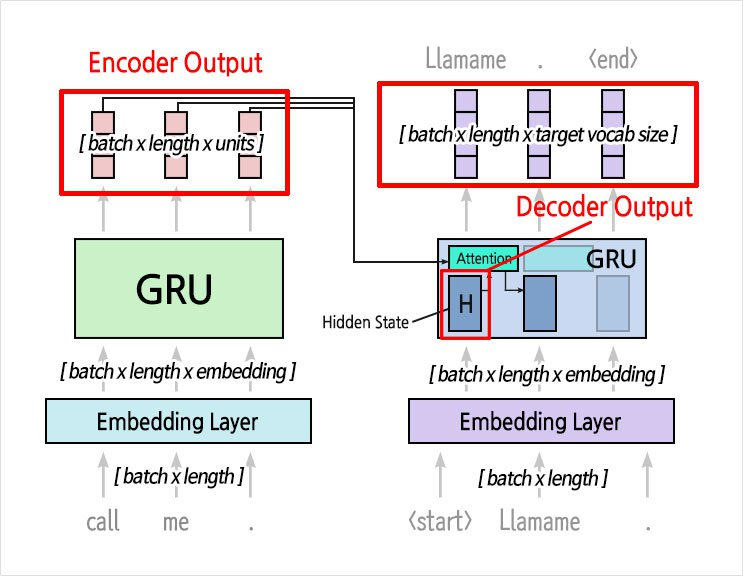

[GRU 구조]

Encoder는 **모든 Time-Step의 Hidden State를 출력**으로 갖고, Decoder는 **Encoder의 출력**과 Decoder의 **t-1 Step의 Hidden State로 Attention**을 취하여 **t Step의 Hidden State**를 만들어 냅니다.

Decoder에서 t Step의 단어로 예측된 것을 실제 정답과 대조해 Loss를 구하고, 생성된 t Step의 Hidden State는 t+1 Step의 Hidden State를 만들기 위해 다시 Decoder에 전달됩니다.

여기서 '**t=1 일 때의 Hidden State는 어떻게 정의할 것인가?**' 가 궁금하실 수 있는데요, 일반적으로 Encoder의 Final State를 Hidden State로 사용합니다.

Attention은 Bahdanau을 사용할 예정이며, 이는 이전 렉처 노드에서 실습한 코드를 가져다가 쓰도록 할게요.

**Q. Bahdanau Attention을 사용할 예정인데 특징이 뭐였죠?**

<details>
<summary>💡예시답안 확인하기💡</summary>

입력 시퀀스의 각 위치마다 가중치를 학습하여 중요도를 결정합니다. \
즉, 입력 시퀀스의 다른 위치에 대한 주의도가 다를 수 있습니다. 이를 통해 모델이 입력 시퀀스의 특정 부분에 집중하거나 무시할 수 있습니다.
</details>

In [55]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

**위 그림과 동일한 구조를 갖는 `Encoder` 클래스와 `Decoder` 클래스를 설계하고, 아래 소스를 실행해 답안과 같은 결과를 얻으세요.**

In [56]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [57]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [58]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [60]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [61]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(2320, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(2320, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=2320, bias=True)
  )
)


코드를 실행하면 다음과 같은 형식의 결과가 나와야 합니다.

```bash
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): LSTM(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): LSTM(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)
```

<details>
<summary>Encoder 예제 코드</summary>


```python
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, (hidden, cell) = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden, cell
```

</details>


<details>
<summary>Decoder 예제 코드</summary>

```python
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.LSTM(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, cell, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)

        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, cell, a.squeeze(1)
```

</details>

# 훈련하기 (1) Optimizer & Loss
지금까지는 Optimizer 안에 파라미터를 간편하게 입력했지만, Encoder-Decoder 구조의 경우 모델이 분리되어 파라미터를 각각 정의해줘야 합니다. 조금 불편하고 난감하게 다가올 수도 있지만 후에 더 멋진 연구를 하기 위한 발판이 되어 줄 테니 익숙해져 봅시다!

낯선 함수들이 지나치게 많이 등장할 수 있으니, 이번 코스에선 직접 구현을 하기보단 구현체를 먼저 보고 이해하는 방향으로 공부하도록 합시다!

## Optimizer & Loss
---
가장 큰 줄기를 먼저 보고, 점점 더 들어가 보는 방식으로 진행해볼게요. 첫 순서는 **Optimizer와 Loss**입니다!

In [62]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0) 

print("슝~")

슝~


**Optimizer**는 모델이 학습할 때에 정답을 찾아가는 방법 정도로 설명할 수 있는데, 일반적으론 Adam 외의 것을 사용하지 않으니 후에 실력이 더 늘어나고 나서 공부하시는 것을 권장합니다! 우선은 다른 배워야 할 것들이 산더미니까요...😅

`nn.CrossEntropyLoss()` 함수는 **모델이 출력한 확률 분포**와 (One-hot이 아닌) **정수 인덱스 답안**을 비교해 Cross Entropy값을 구해줍니다. `nn.NLLLoss()`라면 `[ 0.1, 0.2, 0.7 ]` 과 One-hot 인코딩된 라벨 `[0, 0, 1]` 을 비교하여 점수를 채점하겠지만, `nn.CrossEntropyLoss()` 함수라면 `[ 0.1, 0.2, 0.7 ]` 과 정수 인덱스 답안 `2` 를 비교하여 점수를 채점하는 거죠.

**Q. 패딩(Padding) 과정을 진행하는 이유가 뭘까요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

효율적인 배치 처리, 메모리 효율성 등이 있습니다.
</details>

만약 모델에게 `<PAD>` 토큰이 **패딩을 위한 토큰이라고 명시하지 않으면** 모델은 데이터의 굉장히 많은 부분이 `<PAD>` 로 이뤄져 있다고 생각하게 됩니다. 쉽게 말해 **유난히 같은 답이 많은 객관식 시험**이라고나 할까요...? 어떤 시험이 한 번호로만 찍어도 80점 이상을 받을 수 있다면 그 시험은 공부를 절대 하지 않겠죠! 모델은 심지어 10,000개의 정답이 넘게 있는 고난도의 문제를 풀고 있기 때문에 **패딩에 대한 처리**를 해주지 않으면 `<PAD>` **토큰만을 생성할 확률이 굉장히 높아집니다.**

이것은 종종 발생하는 문제라서 기억해두시면 좋아요. 이 문제를 방지하기 위해 `mask` 가 사용됩니다! `mask` 는 정답지에서 `<PAD>` 토큰을 찾아내어 그 부분에 대한 Loss는 구하지 않도록 하는 역할을 해주죠. `equal()` 함수에 정확히는 0 이 아닌 `<PAD>` 토큰의 인덱스를 전달하는 것이 맞지만 **대부분의 경우는 0으로 패딩되기 때문에 편의상 0을 전달**하여 처리하도록 하겠습니다.

# 훈련하기 (2) train_step 구현하기
`train_step()`은 학습에 필요한 것을 모두 가져가 **Loss를 계산한 후 반환하는 함수**입니다. 먼저 구성을 보시죠!

In [63]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.view(-1, outputs.shape[-1])
        trg_label = trg_label.view(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


코드를 좀 더 자세히 살펴봅시다.

`train_step()`의 학습 과정은 아래와 같습니다.

1. model.train()을 호출하여 모델을 학습 모드로 전환합니다.
2. optimizer.zero_grad()를 통해 이전 배치에서 계산된 기울기를 초기화합니다.
3. Encoder에 소스 문장을 전달해 **컨텍스트 벡터인 `enc_out` 을 생성**
4. **t=0일 때**, Decoder의 Hidden State는 **Encoder의 Final State로 정의**. `h_dec = enc_hidden`
Encoder 처리
5. `<start>` 문장과 enc_out, Hidden State를 기반으로 **다음 단어(t=1)를 예측**. `predictions`
6. 예측된 단어와 정답 간의 Loss를 구한 후, t=1의 **정답 단어를 다음 입력으로 사용** (예측 단어 사용X)
7. 반복!

코드를 한 줄 한 줄 살피면 이해가 어려운 라인은 없을 거예요.

# 훈련하기 (3) 훈련 시작하기
다음 순서는 본격적으로 **훈련을 시작하는 부분**입니다! (훈련 시간은 약 15분 정도 소요 됩니다.)

In [73]:
%%time

EPOCHS =10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|███████████████████████| 80/80 [01:23<00:00,  1.04s/it, loss=2.76]


Epoch 1/10, Train Loss: 2.5857


Epoch 2: 100%|███████████████████████| 80/80 [01:22<00:00,  1.04s/it, loss=2.67]


Epoch 2/10, Train Loss: 2.5729


Epoch 3: 100%|███████████████████████| 80/80 [01:23<00:00,  1.04s/it, loss=2.66]


...

Epoch 8/10, Train Loss: 2.4805


Epoch 9: 100%|███████████████████████| 80/80 [01:22<00:00,  1.03s/it, loss=2.63]


Epoch 9/10, Train Loss: 2.4620


Epoch 10: 100%|██████████████████████| 80/80 [01:22<00:00,  1.03s/it, loss=2.62]

Epoch 10/10, Train Loss: 2.4519
CPU times: user 18min 4s, sys: 1min 56s, total: 20min
Wall time: 13min 47s


먼저 `tqdm`은 훈련의 진행 과정을 한눈에 볼 수 있게 해주는 라이브러리입니다. 사용법은 위 예제만 봐도 이해가 갈 정도로 정말 간단하니 웬만하면 활용하시는 것을 추천해 드려요! `# tqdm`이 붙은 라인은 모두 출력에 관련된 내용이니 설명을 생략하겠습니다. 궁금하신 분들은 아래 github을 참고하시길 바라요!

- [tqdm/tqdm](https://github.com/tqdm/tqdm)

먼저 `EPOCHS = 10` 만큼 반복하는 루프에 진입한 후, 각 배치의 시작 인덱스를 `idx_list` 배열에 저장합니다. 그리고 모델이 학습을 원활하게 할 수 있도록 데이터를 섞어줘야 하는데요, **인덱스를 섞어서 처리**할 겁니다. 순차적인 인덱스로 데이터를 불러오는 게 아닌 랜덤한 인덱스로 데이터를 불러오는 것은 데이터를 섞는 것과 동일한 효과를 가져오겠죠!

그 후에 각 미니배치를 `train_step()` 함수에서 학습합니다. `train_step()`은 학습에 필요한 것은 모두 가져가 **Loss를 계산한 후 반환하는 함수**였죠!

이번 기회에 Encoder-Decoder 구조의 학습 방법을 마스터하세요! `optimizer`와 `loss`, `train_step()`까지 정의한 후 훈련을 시작하면 아래와 같은 결과를 확인할 수 있습니다.


```
Epoch 1: 100%|██████████| 375/375 [02:38<00:00,  2.37it/s, loss=1.54]
Epoch 1/10, Train Loss: 1.7942
Epoch 2: 100%|██████████| 375/375 [02:46<00:00,  2.25it/s, loss=1.4]
Epoch 2/10, Train Loss: 1.4438

...

Epoch 10: 100%|██████████| 375/375 [02:49<00:00,  2.21it/s, loss=1.27]
Epoch 10/10, Train Loss: 1.2092

```


## 실습하기
---
이제 직접 실습해 볼까요?

**Step 1에서 분리한 Validation Set을 사용하는 `eval_step()` 함수를 정의하세요! 그리고 train_step() 을 마친 후, 곧이어 `eval_step()` 을 진행하도록 소스를 수정하세요! 결과는 아래와 같은 형태가 되어야 합니다.**

(주의! Evaluation 중에는 모델이 학습을 해서는 안 됩니다!)


```bash
Epoch  1: 100%|██████████| 375/375 [00:50<00:00,  7.45it/s, Loss 1.7839]
Test Epoch  1: 100%|██████████| 94/94 [00:09<00:00,  9.75it/s, Test Loss 1.4220]
Epoch  2: 100%|██████████| 375/375 [00:31<00:00, 11.74it/s, Loss 1.2333]
Test Epoch  2: 100%|██████████| 94/94 [00:02<00:00, 46.58it/s, Test Loss 1.1305]
Epoch  3: 100%|██████████| 375/375 [00:31<00:00, 11.77it/s, Loss 0.9801]
Test Epoch  3: 100%|██████████| 94/94 [00:01<00:00, 48.42it/s, Test Loss 0.9771]
Epoch  4: 100%|██████████| 375/375 [00:31<00:00, 11.74it/s, Loss 0.7998]
Test Epoch  4: 100%|██████████| 94/94 [00:02<00:00, 46.70it/s, Test Loss 0.8701]
Epoch  5: 100%|██████████| 375/375 [00:31<00:00, 11.81it/s, Loss 0.6553]
Test Epoch  5: 100%|██████████| 94/94 [00:01<00:00, 47.60it/s, Test Loss 0.7903]
...
```



In [74]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        outputs, _ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.view(-1, outputs.shape[-1])
        trg_label = trg_label.view(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [75]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|███████████████████████| 80/80 [01:22<00:00,  1.04s/it, loss=2.61]


Epoch 1/20, Train Loss: 2.4333, Validation Loss: 4.4071


Epoch 2: 100%|███████████████████████| 80/80 [01:22<00:00,  1.03s/it, loss=2.61]


Epoch 2/20, Train Loss: 2.4260, Validation Loss: 4.4433


Epoch 3: 100%|███████████████████████| 80/80 [01:22<00:00,  1.04s/it, loss=2.57]


...

Epoch 18/20, Train Loss: 2.2882, Validation Loss: 4.6551


Epoch 19: 100%|██████████████████████| 80/80 [01:22<00:00,  1.04s/it, loss=2.42]


Epoch 19/20, Train Loss: 2.2766, Validation Loss: 4.6450


Epoch 20: 100%|███████████████████████| 80/80 [01:22<00:00,  1.03s/it, loss=2.4]


Epoch 20/20, Train Loss: 2.2787, Validation Loss: 4.6657
CPU times: user 40min 11s, sys: 4min 33s, total: 44min 45s
Wall time: 30min 30s


훈련이 완료된 모델은 아래 소스를 실행해 번역 성능을 평가할 수 있어요. Attention Map을 시각화하는 것은 보너스!

In [76]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [77]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [78]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['', '샀', '다', '.', '']


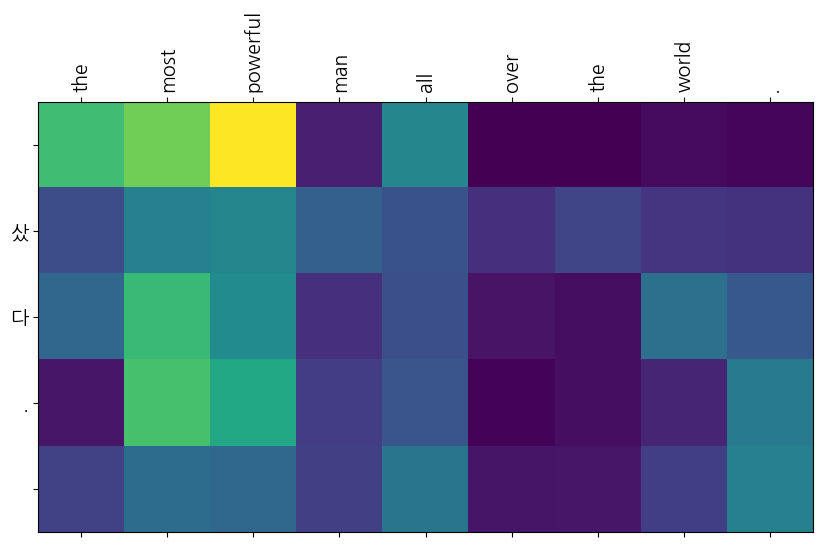

In [79]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['화장실', '의', '학생이', '있어', '.', '']


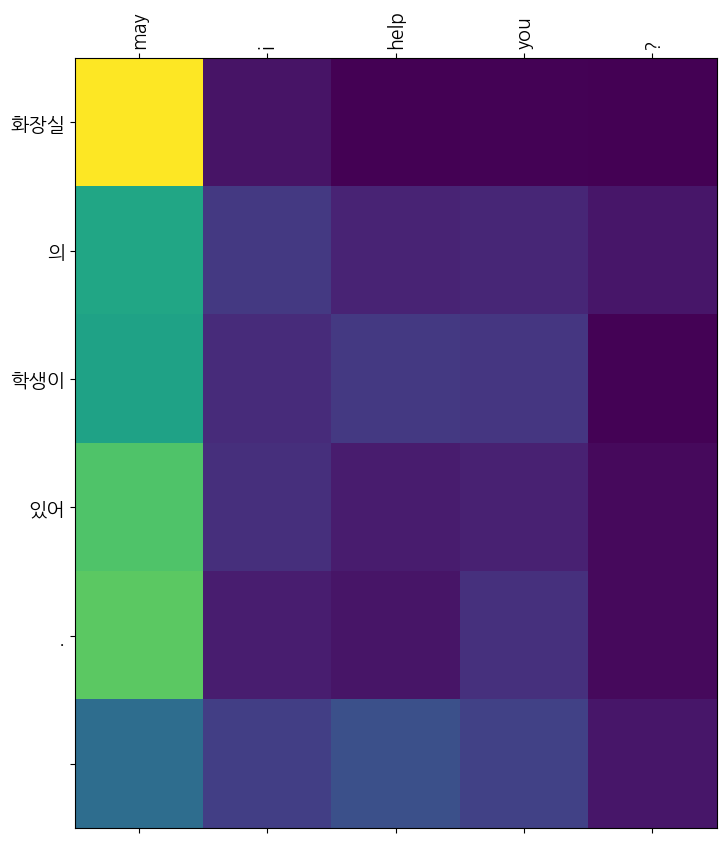

In [80]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['', '뭐', '예요', '?', '']


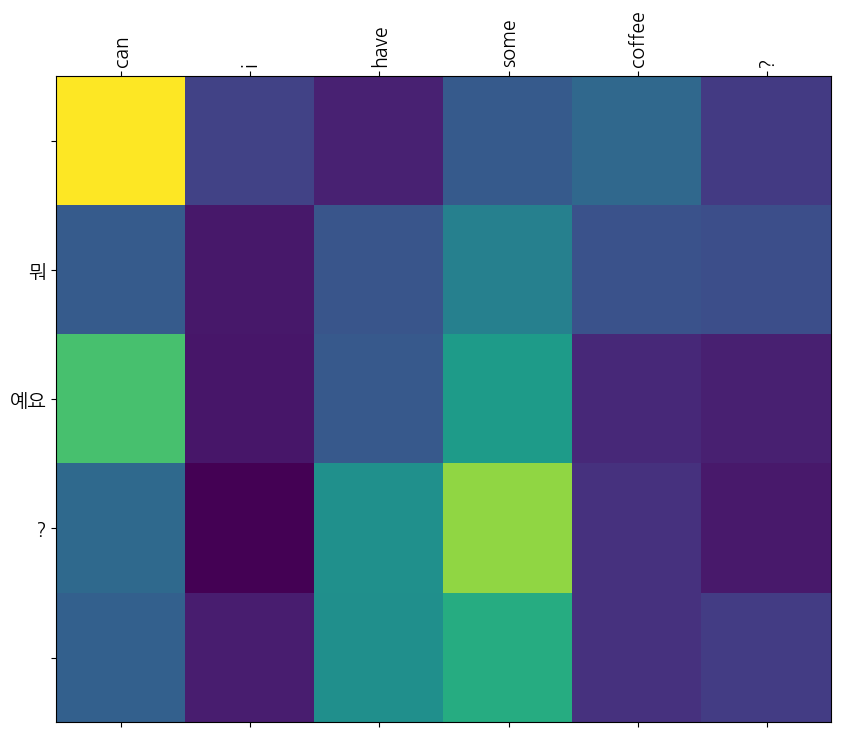

In [81]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

아래와 같은 맵이 나오면 성공입니다.

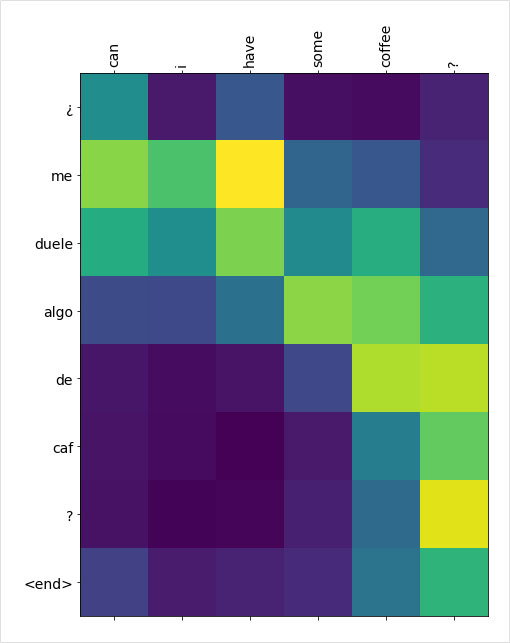

<details><summary>eval_step 예시 코드</summary>


```python
# Define eval_step

def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        outputs, _ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.view(-1, outputs.shape[-1])
        trg_label = trg_label.view(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")


# Training Process

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')
```
</details>